# Universal Automatic Elbow Detection (G-UAED) for Lasso (non-uniform sampling)

This notebook implements the Generalized Universal Automatic Elbow Detection (G-UAED) algorithm, originally written in MATLAB by Samuel Escudero, Luca Martino, Roberto San Millán, and Eduardo Morgado.

It loads error curves and finds the optimal elbow point as well as an uncertainty interval.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import os

In [2]:
def interval_aed_fun_lasso(V, kx):
    """
    Calculates the uncertainty interval for the elbow point.
    
    Parameters:
    V (numpy.ndarray): Error curve values.
    kx (numpy.ndarray): Number of links (x-axis).
    
    Returns:
    list: [k_1^*, k_2^*] defining the uncertainty interval.
    """
    V = V - np.min(V)
    kmax = kx[-1]
    
    min_now = float('inf')
    indices_now = [None, None]
    x = kx
    x2 = kx
    
    # Iterate through all pairs of points
    for i in range(len(x)):
        for j in range(i + 1, len(x)):
            # Calculate areas of the three regions (trapezoid, trapezoid, triangle)
            A1 = ((V[0] + V[i]) * (x[i] - x[0])) / 2.0 if i > 0 else 0 # Adjusted to include (x[i] - x[0]) as per paper mathematically
            # original MATLAB code has A1=((V(1)+V(i))*x(i))/2 which implicitly assumes x[0] is 0 or very close.
            A1 = ((V[0] + V[i]) * x[i]) / 2.0
            
            A2 = ((V[i] + V[j]) * (x2[j] - x[i])) / 2.0
            
            A3 = ((kmax - x2[j]) * V[j]) / 2.0
            
            E2 = A1 + A2 + A3
            
            if E2 < min_now:
                min_now = E2
                indices_now = [kx[i], kx[j]]
                
    return indices_now

In [ ]:
# === Configuration ===
# file_path = 'data/example_curves/Curva_noth_err_out.mat' # Path to the .mat or .npy file
# file_type = '.mat' # '.mat' or '.npy'
file_path = 'results/opt_lamb_araus_no_stdY/sem_und_withth_err.npy'
file_type = '.npy' # '.mat' or '.npy'

# Text to display on the plot (optional)
plot_text = [
    "Looking just the",
    "connections of the two outputs",
    "with possible inter-link"
]
text_x_pos = 27
text_y_pos_start = 0.68

# Custom axis limits (optional, set to None for default)
axis_limits = None # e.g., [100, 2500, 0, 0.08]
# Save Figure Configuration
SAVE = True
SELECTED_KEY = 'A' # Change to 'B', 'C', or 'D' as needed
# =====================

In [4]:
# === Load Data ===
if file_type == '.mat':
    mat_data = scipy.io.loadmat(file_path)
    # Attempt to automatically find the data matrix (usually 'A', 'B', 'C', 'D' or similar in MATLAB)
    data_keys = [k for k in mat_data.keys() if not k.startswith('__')]
    
    # EXPLANATION OF KEYS (MATLAB Variables):
    # KEY 'A' (e.g., Curva_noth_err_out.mat): Looking just the connections of the two outputs with possible inter-link
    # KEY 'B' (e.g., Curva_noth_err.mat): Considering all the connections with all the variables (with possible link within the two outputs)
    # KEY 'C' (e.g., Curva_UNC_noth_err_out.mat): Looking just the connections of the two outputs WITHOUT possible inter-link
    # KEY 'D' (e.g., Curva_UNC_noth_err.mat): Considering all the connections with all the variables (WITHOUT possible link within the two outputs)
    
    if SELECTED_KEY in mat_data:
        data_matrix = mat_data[SELECTED_KEY]
        print(f"Loaded key '{SELECTED_KEY}'")
    else:
        raise ValueError(f"Key '{SELECTED_KEY}' not found in the .mat file. Available keys: {data_keys}")
        
elif file_type == '.npy':
    data_matrix = np.load(file_path)
else:
    raise ValueError("Unsupported file_type. Please use '.mat' or '.npy'")

print(f"Loaded data from {file_path} with shape {data_matrix.shape}")

Loaded data from data/example_curves/Curva_noth_err_out.mat with shape (33, 3)


In [5]:
# === Data Processing ===
# The MATLAB code reverses the array: A(end:-1:1, :)
A = data_matrix[::-1, :]

lambdaLASSO = A[:, 0]
kx = A[:, 1]
V = A[:, 2]

# Normalize V
V = V - np.min(V)

# Point Estimation (Geometric method from MATLAB)
lam = V[0] / kx[-1]
aux = np.abs((V[0] - lam * kx) - V)

# Find max distance point
pos_max = np.argmax(aux)
Elbow2 = kx[pos_max]
optimal_lambda = lambdaLASSO[pos_max]

# Interval Estimation (G-UAED)
interval_links = interval_aed_fun_lasso(V, kx)

# Find corresponding lambdas for the interval
pos_int_1 = np.where(kx == interval_links[0])[0][0]
pos_int_2 = np.where(kx == interval_links[1])[0][0]
interval_lambda = [lambdaLASSO[pos_int_1], lambdaLASSO[pos_int_2]]

print('-' * 52)
print('RESULTS')
print('-' * 52)
print(f'Optimal number of links: {Elbow2}')
print('-' * 52)
print(f'Optimal lambda of LASSO: {optimal_lambda}')
print('-' * 52)
print(f'Uncertainty interval (links): {interval_links}')
print(f'Uncertainty interval (lambda): {interval_lambda}')
print('-' * 52)

----------------------------------------------------
RESULTS
----------------------------------------------------
Optimal number of links: 10.0
----------------------------------------------------
Optimal lambda of LASSO: 159.7817515520133
----------------------------------------------------
Uncertainty interval (links): [6.0, 23.0]
Uncertainty interval (lambda): [472.5939130411661, 34.65688695635218]
----------------------------------------------------


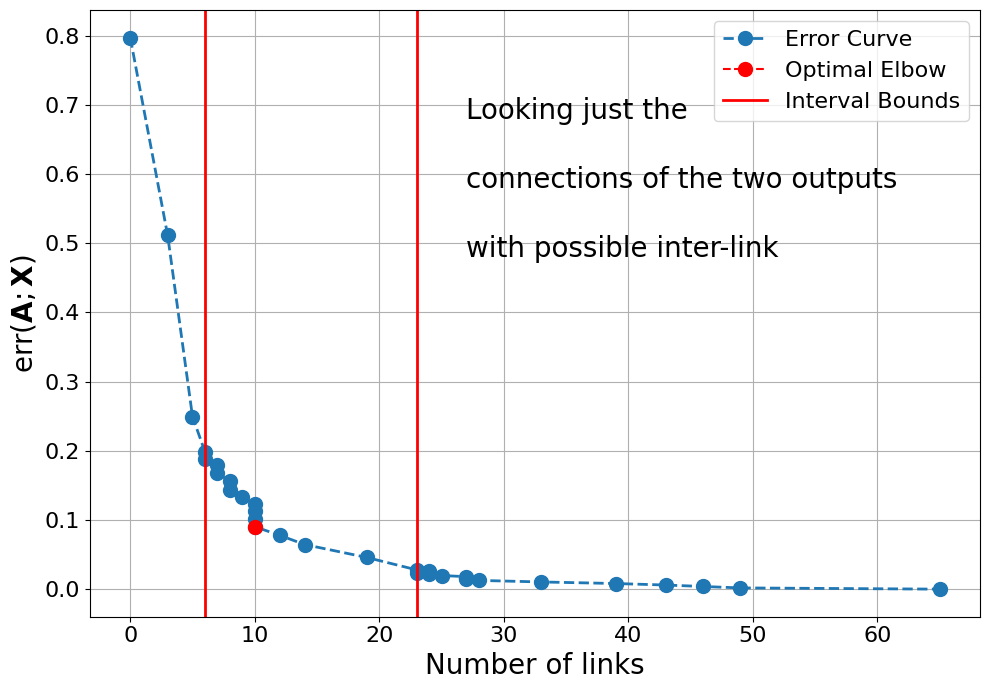

In [6]:
# === Plotting ===
plt.figure(figsize=(10, 7))
plt.plot(kx, V, 'o--', linewidth=2, markersize=10)
plt.plot(Elbow2, V[pos_max], 'ro--', markerfacecolor='r', markersize=10)

# Plot Interval Lines
plt.axvline(x=interval_links[0], color='r', linestyle='-', linewidth=2)
plt.axvline(x=interval_links[1], color='r', linestyle='-', linewidth=2)

# Formatting
plt.xlabel('Number of links', fontsize=20)
plt.ylabel(r'$\mathrm{err}(\mathbf{A}; \mathbf{X})$', fontsize=20) # Using raw string for LaTeX interpretation
plt.box(True)
plt.grid(True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Optional texts
if plot_text and text_x_pos is not None and text_y_pos_start is not None:
    y_pos = text_y_pos_start
    for line in plot_text:
        plt.text(text_x_pos, y_pos, line, fontsize=20)
        y_pos -= 0.1 # Move down for next line, adjust as needed

if axis_limits:
    plt.axis(axis_limits)

plt.tight_layout()

if SAVE:
    import os
    os.makedirs('results/guad', exist_ok=True)
    plt.savefig('results/guad/elbow_plot.png', dpi=300, bbox_inches='tight')
    plt.savefig('results/guad/elbow_plot.pdf', bbox_inches='tight')
    print("Figura guardada en results/guad/elbow_plot.png y .pdf")

plt.show()